<!-- [reviewer-header] auto-generated; safe to keep at the top of the notebook -->


## Reviewer notes

**What this notebook does.** Reads JSON outputs from notebooks 01–05 and produces the paper's composite figures (three-model LOO, per-sequence heatmap, cross-architecture emergence).

**Paper section.** Composite figures referenced from §3 and the discussion

**Outputs.** 6 PNGs (no new JSONs; reads from existing JSONs).

**Hardware / runtime.** CPU, ~~1 min.

**How to run from a fresh GitHub clone.**

1. Click the "Open in Colab" badge above (or upload to Kaggle / run locally).
2. The first code cell installs all dependencies via `pip`.
3. Output paths auto-detect the runtime: Colab Drive (`/content/drive/MyDrive/MIDU/`), Kaggle (`/kaggle/working/`), or a local `./mldu_e_work/` directory. No manual setup is required if you accept the defaults.
4. Mistral-7B notebooks additionally need an `HF_TOKEN` (Colab → Secrets, Kaggle → Add-ons → Secrets, or `os.environ['HF_TOKEN']` locally).

---


# Orphan Figure Generation

Generates six figures referenced in the paper that are not produced by the five main notebooks. All inputs are existing JSON results — no model runs, no GPU.

**Inputs** (expected in the same directory as this notebook, or set `RESULTS_DIR` below):
- `R1_results.json`   — GPT-2 medium LOO cross-sequence probe
- `R2_results.json`   — Pythia-70M LOO cross-sequence probe
- `E3_results.json`   — Mistral-7B LOO cross-sequence probe
- `R3_results.json`   — Natural-vs-injected probe comparison
- `R3B_results.json`  — Multi-secret injected memorization LOO
- `R3C_pilot_v2_results.json` — Unlearning feasibility pilot

**Outputs** (written to `FIGURES_DIR`):
- `fig_loo_three_models.png`         — cross-architecture LOO comparison
- `fig_loo_per_sequence_heatmap.png` — per-sequence LOO heatmaps for 3 models
- `fig_emergence.png`                — LOO gap vs normalized depth, 3 models
- `fig_r3_natural_vs_injected.png`   — R3 cross-regime probe
- `fig_r3b_injected_loo.png`         — R3B multi-secret LOO
- `fig_r3c_feasibility.png`          — R3C config sweep


## Setup

In [3]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# --- Paths: edit if your files live elsewhere ---
RESULTS_DIR = '/content'   # folder with the JSONs
FIGURES_DIR = '/content'   # folder where PNGs will be written

os.makedirs(FIGURES_DIR, exist_ok=True)

# --- Consistent style ---
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.family': 'serif',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

COLOR_TRUE = '#d62728'      # red
COLOR_SHUFF = '#7f7f7f'     # grey
COLOR_PURE = '#1f77b4'      # blue
COLOR_UNL = '#2ca02c'       # green

def load(name):
    path = os.path.join(RESULTS_DIR, name)
    with open(path) as f:
        return json.load(f)

def save_fig(name):
    out = os.path.join(FIGURES_DIR, name)
    plt.savefig(out, bbox_inches='tight')
    print(f'  saved: {out}')

print('Setup OK.')

Setup OK.


## 1. `fig_loo_three_models.png`

Cross-architecture LOO probe comparison. Three panels (Pythia-70M / GPT-2 medium / Mistral-7B) showing True vs Shuffled vs Pure-string LOO mean accuracy by depth, with shaded std band around True.

  saved: /content/fig_loo_three_models.png


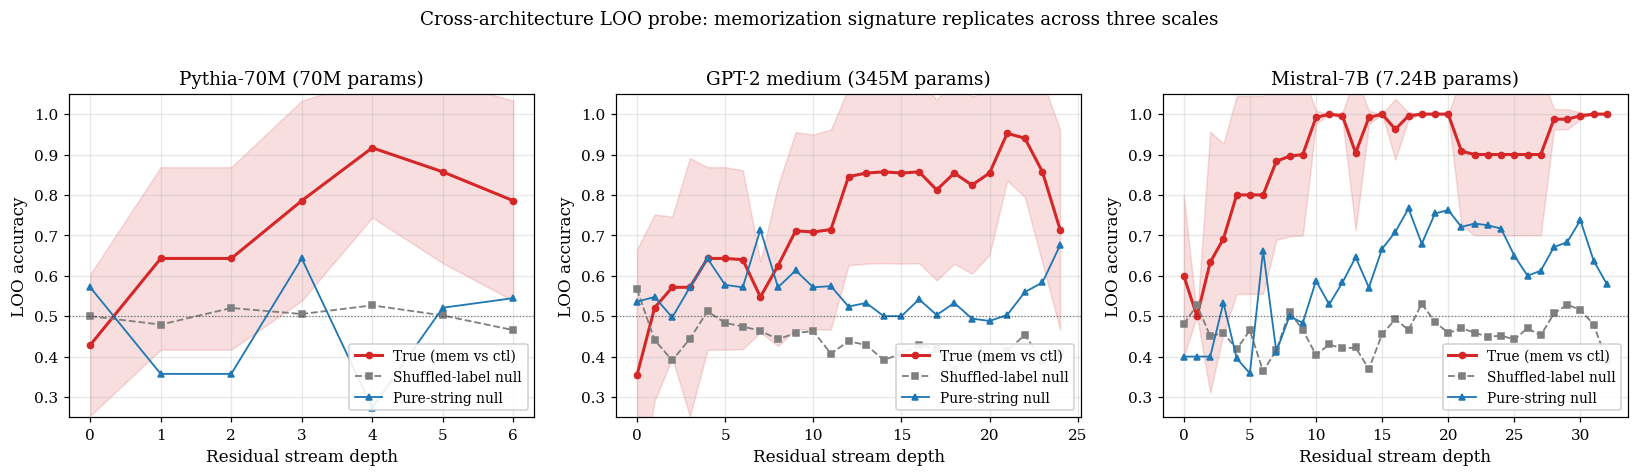

In [4]:
def extract_per_depth(loo_dict):
    """Given {'0': {mean, std, per_seq}, '1': ...} → (depths, means, stds)."""
    depths = sorted(loo_dict.keys(), key=int)
    means = np.array([loo_dict[d]['mean'] for d in depths])
    stds = np.array([loo_dict[d].get('std', 0.0) for d in depths])
    return np.array([int(d) for d in depths]), means, stds

models = [
    ('R2_results.json', 'Pythia-70M (70M params)'),
    ('R1_results.json', 'GPT-2 medium (345M params)'),
    ('E3_results.json', 'Mistral-7B (7.24B params)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (fn, title) in zip(axes, models):
    d = load(fn)
    depths, true_m, true_s = extract_per_depth(d['loo_true'])
    _, shuff_m, _ = extract_per_depth(d['loo_shuffled'])
    _, pure_m, _ = extract_per_depth(d['loo_pure'])
    ax.plot(depths, true_m, 'o-', color=COLOR_TRUE, label='True (mem vs ctl)', lw=2, ms=4)
    ax.fill_between(depths, true_m - true_s, true_m + true_s, color=COLOR_TRUE, alpha=0.15)
    ax.plot(depths, shuff_m, 's--', color=COLOR_SHUFF, label='Shuffled-label null', lw=1.2, ms=3.5)
    ax.plot(depths, pure_m, '^-', color=COLOR_PURE, label='Pure-string null', lw=1.2, ms=3.5)
    ax.axhline(0.5, color='k', ls=':', lw=0.8, alpha=0.5)
    ax.set_ylim(0.25, 1.05)
    ax.set_xlabel('Residual stream depth')
    ax.set_ylabel('LOO accuracy')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', framealpha=0.9)

fig.suptitle('Cross-architecture LOO probe: memorization signature replicates across three scales', y=1.02)
plt.tight_layout()
save_fig('fig_loo_three_models.png')
plt.show()

## 2. `fig_loo_per_sequence_heatmap.png`

Per-sequence LOO accuracy heatmaps for the three architectures — rows are memorized sequences, columns are residual-stream depths.

  saved: /content/fig_loo_per_sequence_heatmap.png


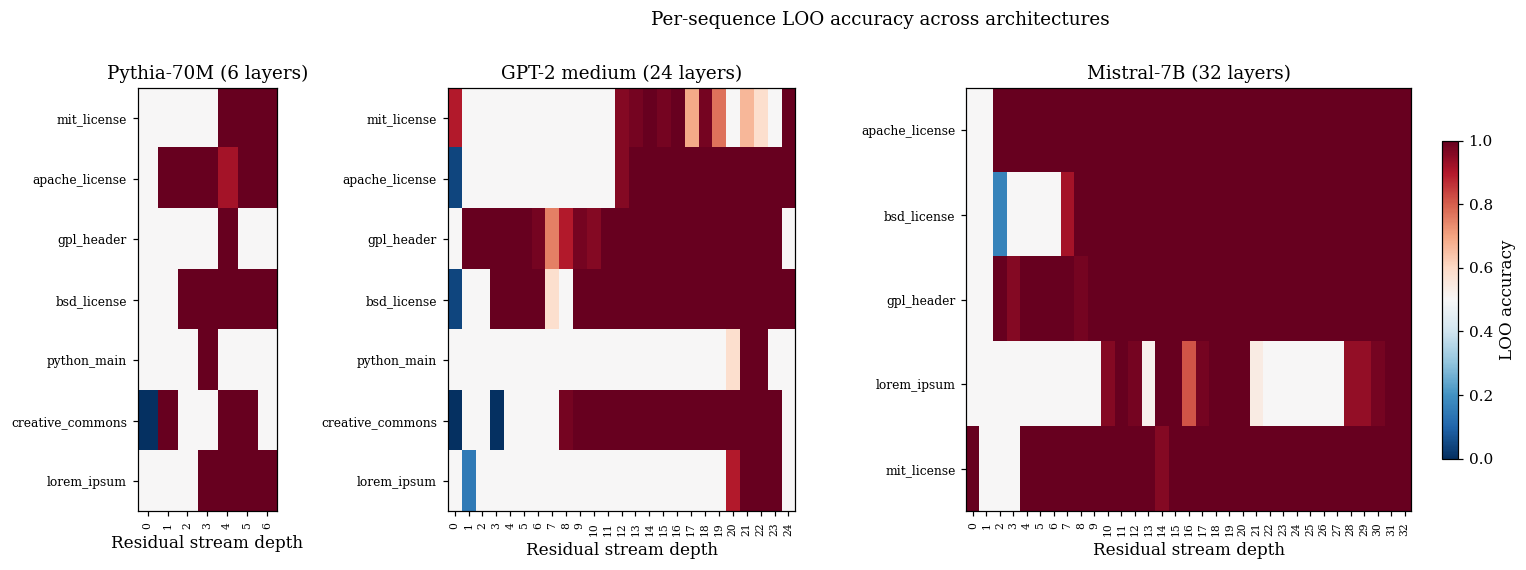

In [5]:
def build_heatmap_matrix(d):
    """From loo_true['d']['per_seq'] → (seq_names, depths, matrix)."""
    lt = d['loo_true']
    depths = sorted(lt.keys(), key=int)
    # Sequence names: union of keys across depths (usually same)
    seq_names = list(lt[depths[0]]['per_seq'].keys())
    matrix = np.zeros((len(seq_names), len(depths)))
    for j, depth in enumerate(depths):
        per = lt[depth]['per_seq']
        for i, name in enumerate(seq_names):
            matrix[i, j] = per.get(name, np.nan)
    return seq_names, [int(x) for x in depths], matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                         gridspec_kw={'width_ratios': [1.0, 2.5, 3.2], 'wspace': 0.55})
titles = ['Pythia-70M (6 layers)', 'GPT-2 medium (24 layers)', 'Mistral-7B (32 layers)']
files = ['R2_results.json', 'R1_results.json', 'E3_results.json']

im = None
for i, (ax, fn, title) in enumerate(zip(axes, files, titles)):
    d = load(fn)
    names, depths, M = build_heatmap_matrix(d)
    im = ax.imshow(M, aspect='auto', cmap='RdBu_r', vmin=0.0, vmax=1.0, origin='upper')
    ax.set_xticks(range(len(depths)))
    ax.set_xticklabels([f'{d_}' for d_ in depths], fontsize=7, rotation=90)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel('Residual stream depth')
    ax.set_title(title)

cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.75, pad=0.02)
cbar.set_label('LOO accuracy')
fig.suptitle('Per-sequence LOO accuracy across architectures', y=1.02)
save_fig('fig_loo_per_sequence_heatmap.png')
plt.show()

## 3. `fig_emergence.png`

LOO gap (True − Pure) by *normalized* depth (depth / n_layers), overlaying the three architectures so the emergence pattern is comparable despite different layer counts.

  saved: /content/fig_emergence.png


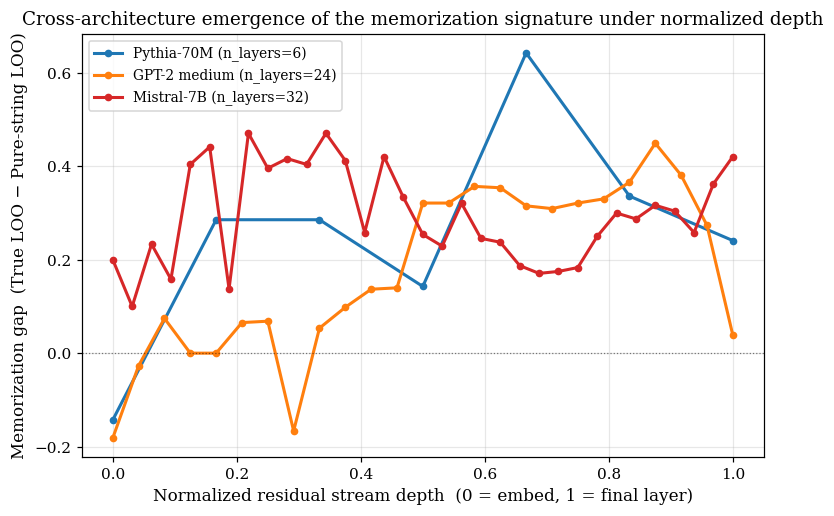

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for fn, label, color in [
    ('R2_results.json', 'Pythia-70M', '#1f77b4'),
    ('R1_results.json', 'GPT-2 medium', '#ff7f0e'),
    ('E3_results.json', 'Mistral-7B', '#d62728'),
]:
    d = load(fn)
    depths, true_m, _ = extract_per_depth(d['loo_true'])
    _, pure_m, _ = extract_per_depth(d['loo_pure'])
    gap = true_m - pure_m
    # Normalize depth to [0, 1]
    norm = depths / max(depths) if max(depths) > 0 else depths
    ax.plot(norm, gap, 'o-', color=color, label=f'{label} (n_layers={max(depths)})', lw=2, ms=4)

ax.axhline(0, color='k', ls=':', lw=0.8, alpha=0.5)
ax.set_xlabel('Normalized residual stream depth  (0 = embed, 1 = final layer)')
ax.set_ylabel('Memorization gap  (True LOO − Pure-string LOO)')
ax.set_title('Cross-architecture emergence of the memorization signature under normalized depth')
ax.grid(True, alpha=0.3)
ax.legend()
save_fig('fig_emergence.png')
plt.show()

## 4. `fig_r3_natural_vs_injected.png`

R3 — a probe trained on naturally-memorized sequences does not flag the injected secret. Shows LOO-target accuracy at each depth for memorized vs unlearned model.

  saved: /content/fig_r3_natural_vs_injected.png


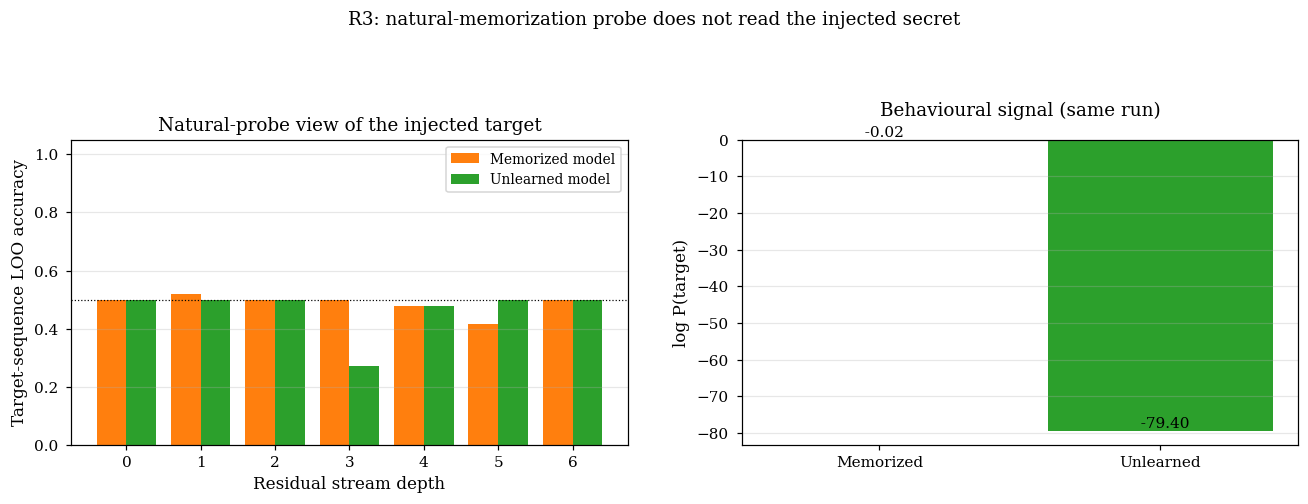

In [17]:
d = load('R3_results.json')
lt = d['loo_target_per_depth']
mem = lt['memorized']
unl = lt['unlearned']
depths = sorted(mem.keys(), key=int)
x = np.array([int(dp) for dp in depths])

mem_vals = np.array([mem[dp] for dp in depths])
unl_vals = np.array([unl[dp] for dp in depths])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: bar plot at each depth, mem vs unlearned
width = 0.4
ax1.bar(x - width/2, mem_vals, width, color='#ff7f0e', label='Memorized model')
ax1.bar(x + width/2, unl_vals, width, color=COLOR_UNL, label='Unlearned model')
ax1.axhline(0.5, color='k', ls=':', lw=0.8)
ax1.set_ylim(0, 1.05)
ax1.set_xlabel('Residual stream depth')
ax1.set_ylabel('Target-sequence LOO accuracy')
ax1.set_title('Natural-probe view of the injected target')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='y', pad=5) # Add padding to y-axis tick labels

# Right: behavioral signal as reference
ax2.bar(['Memorized', 'Unlearned'], [d['log_p_memorized'], d['log_p_unlearned']],
        color=['#ff7f0e', COLOR_UNL])
ax2.set_ylabel('log P(target)')
ax2.set_title('Behavioural signal (same run)', y=1.05) # Adjusted title position
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([d['log_p_memorized'], d['log_p_unlearned']]):
    # Adjust the y-position and vertical alignment to ensure text is above the bar
    ax2.text(i, v + 0.05, f'  {v:.2f}', ha='center', va='bottom')
ax2.tick_params(axis='y', pad=5) # Add padding to y-axis tick labels

fig.suptitle('R3: natural-memorization probe does not read the injected secret', y=1.08) # Increased y to move title up
plt.tight_layout(w_pad=3) # Added w_pad for horizontal spacing
save_fig('fig_r3_natural_vs_injected.png')
plt.show()

## 5. `fig_r3b_injected_loo.png`

R3B — per-secret LOO accuracy by depth for the memorized and unlearned models, with the pure-distinguishability baseline.

  saved: /content/fig_r3b_injected_loo.png


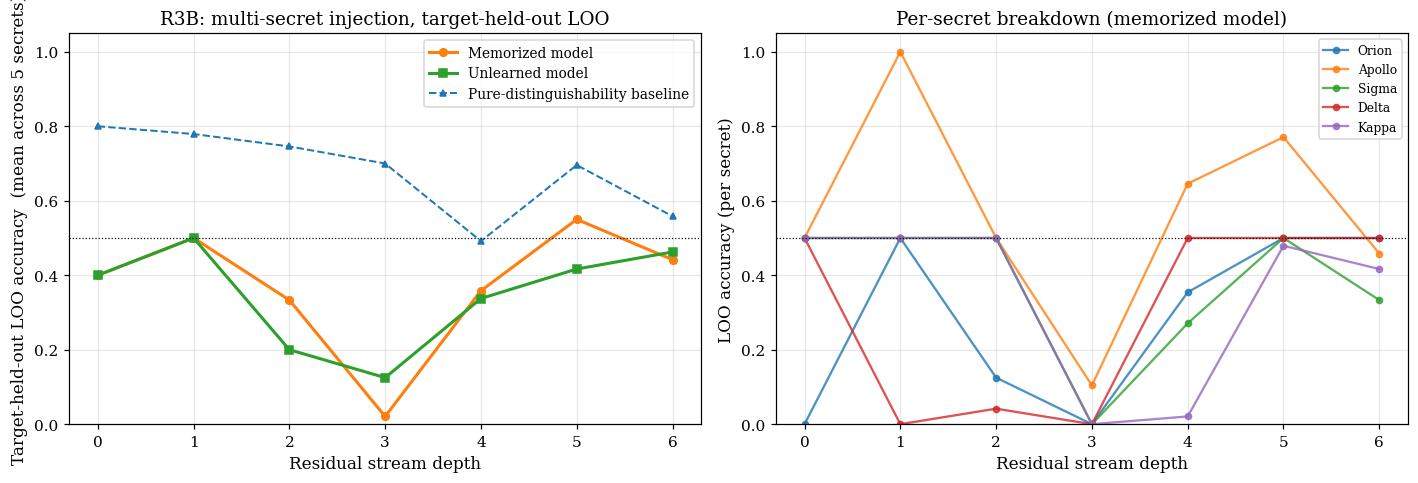


Summary from JSON: {
  "target_mem_loo_mean": 0.3298611111111111,
  "target_unl_loo_mean": 0.2638888888888889,
  "pure_loo_mean": 0.6618055555555554,
  "signature_retention": -0.39791666666666653,
  "signature_drop": 0.06597222222222221
}


In [8]:
d = load('R3B_results.json')
mem = d['loo_memorized_model']
unl = d['loo_unlearned_model']
pure = d['loo_pure']

depths = sorted(mem.keys(), key=int)
x = np.array([int(dp) for dp in depths])

# For each depth, the value is dict of secret -> LOO. Compute mean over secrets.
def depth_means(dct):
    out = []
    for dp in depths:
        v = dct[dp]
        if isinstance(v, dict):
            out.append(np.mean(list(v.values())))
        else:
            out.append(v)
    return np.array(out)

mem_m = depth_means(mem)
unl_m = depth_means(unl)
pure_m = depth_means(pure)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: mean LOO by depth
ax1.plot(x, mem_m, 'o-', color='#ff7f0e', label='Memorized model', lw=2, ms=5)
ax1.plot(x, unl_m, 's-', color=COLOR_UNL, label='Unlearned model', lw=2, ms=5)
ax1.plot(x, pure_m, '^--', color=COLOR_PURE, label='Pure-distinguishability baseline', lw=1.3, ms=4)
ax1.axhline(0.5, color='k', ls=':', lw=0.8)
ax1.set_ylim(0, 1.05)
ax1.set_xlabel('Residual stream depth')
ax1.set_ylabel('Target-held-out LOO accuracy  (mean across 5 secrets)')
ax1.set_title('R3B: multi-secret injection, target-held-out LOO')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: per-secret spaghetti plot on memorized model
secrets = list(mem[depths[0]].keys()) if isinstance(mem[depths[0]], dict) else []
for sec in secrets:
    vals = [mem[dp][sec] for dp in depths]
    ax2.plot(x, vals, 'o-', label=sec, lw=1.5, ms=4, alpha=0.8)
ax2.axhline(0.5, color='k', ls=':', lw=0.8)
ax2.set_ylim(0, 1.05)
ax2.set_xlabel('Residual stream depth')
ax2.set_ylabel('LOO accuracy (per secret)')
ax2.set_title('Per-secret breakdown (memorized model)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_fig('fig_r3b_injected_loo.png')
plt.show()

# Echo the summary for sanity
print('\nSummary from JSON:', json.dumps(d['summary'], indent=2))

## 6. `fig_r3c_feasibility.png`

R3C — the five unlearning configurations tested, showing target log-P drop vs held-out-PPL ratio, with the feasibility box annotated.

  saved: /content/fig_r3c_feasibility.png


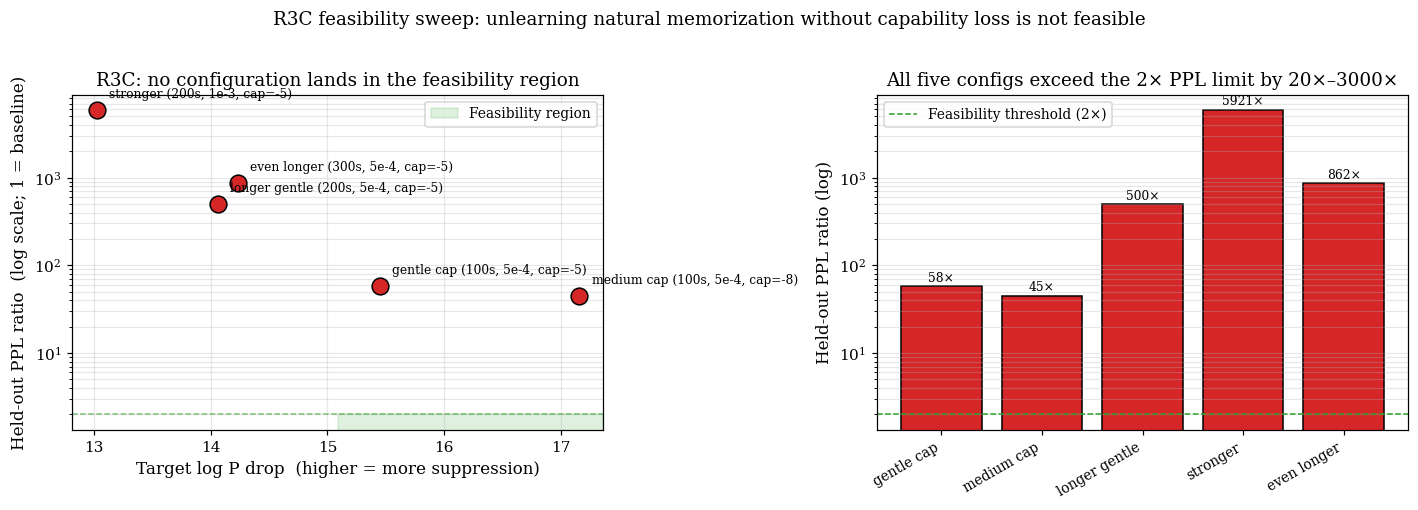


Baseline held-out PPL: 181.29
Feasible: False


In [14]:
d = load('R3C_pilot_v2_results.json')
cfgs = d['configs_tested']
baseline_ppl = d['baseline_held_out_ppl']

labels = [c['label'] for c in cfgs]
target_drops = [c['target_drop'] for c in cfgs]
ppl_ratios = [c['ppl_ratio'] for c in cfgs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: scatter of target_drop vs ppl_ratio (log scale)
ax1.scatter(target_drops, ppl_ratios, s=120, c='#d62728', zorder=3, edgecolor='black', lw=1)
for i, lbl in enumerate(labels):
    ax1.annotate(lbl, (target_drops[i], ppl_ratios[i]),
                 xytext=(8, 8), textcoords='offset points', fontsize=8) # Adjusted xytext to move label up
# Shade the feasibility region (target_drop > 3, ppl_ratio < 2)
ax1.axhspan(0, 2, xmin=0.5, xmax=1.0, color=COLOR_UNL, alpha=0.15, label='Feasibility region')
ax1.axhline(2, color=COLOR_UNL, ls='--', lw=1, alpha=0.6)
ax1.set_yscale('log')
ax1.set_xlabel('Target log P drop  (higher = more suppression)')
ax1.set_ylabel('Held-out PPL ratio  (log scale; 1 = baseline)')
ax1.set_title('R3C: no configuration lands in the feasibility region')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend()

# Right: bar chart of ppl ratios
short = [l.split('(')[0].strip() for l in labels]
bars = ax2.bar(range(len(cfgs)), ppl_ratios, color='#d62728', edgecolor='black')
ax2.set_yscale('log')
ax2.set_xticks(range(len(cfgs)))
ax2.set_xticklabels(short, rotation=30, ha='right', fontsize=9)
ax2.axhline(2, color=COLOR_UNL, ls='--', lw=1, label='Feasibility threshold (2\u00d7)')
ax2.set_ylabel('Held-out PPL ratio (log)')
ax2.set_title('All five configs exceed the 2\u00d7 PPL limit by 20\u00d7\u20133000\u00d7')
ax2.grid(True, alpha=0.3, axis='y', which='both')
ax2.legend()
for bar, ratio in zip(bars, ppl_ratios):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05, f'{ratio:.0f}\u00d7', # Adjusted y position
             ha='center', va='bottom', fontsize=8)

fig.suptitle('R3C feasibility sweep: unlearning natural memorization without capability loss is not feasible',
             y=1.02)
plt.tight_layout()
save_fig('fig_r3c_feasibility.png')
plt.show()

print(f'\nBaseline held-out PPL: {baseline_ppl:.2f}')
print(f'Feasible: {d["feasible"]}')

## Done

All six orphan figures generated. If you see them in the output cells above and the files appear in `./figures/`, you can copy them alongside the paper source and the `\includegraphics` references will resolve.

In [10]:
import os
expected = [
    'fig_loo_three_models.png',
    'fig_loo_per_sequence_heatmap.png',
    'fig_emergence.png',
    'fig_r3_natural_vs_injected.png',
    'fig_r3b_injected_loo.png',
    'fig_r3c_feasibility.png',
]
print('Expected orphan figures — existence check:')
for f in expected:
    path = os.path.join(FIGURES_DIR, f)
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    mark = '✓' if exists else '✗'
    print(f'  {mark}  {f:40s} ({size:,} bytes)' if exists else f'  {mark}  {f:40s} MISSING')

Expected orphan figures — existence check:
  ✓  fig_loo_three_models.png                 (333,117 bytes)
  ✓  fig_loo_per_sequence_heatmap.png         (134,746 bytes)
  ✓  fig_emergence.png                        (183,131 bytes)
  ✓  fig_r3_natural_vs_injected.png           (120,495 bytes)
  ✓  fig_r3b_injected_loo.png                 (275,166 bytes)
  ✓  fig_r3c_feasibility.png                  (223,035 bytes)
